# Relazione finale — Impatto della quantizzazione (PTQ) su Qwen2.5-Coder-1.5B

Progetto sull'effetto della quantizzazione post-training (PTQ) sulla capacità di generazione di codice degli LLM.

## 1. Introduzione

Il punto di partenza è una domanda abbastanza pratica: se prendo un modello di linguaggio specializzato nella generazione di codice e lo comprimo (quantizzazione post-training, PTQ) per farlo girare su hardware più modesto, quanto ci rimetto in termini di qualità del codice generato? E soprattutto: il tipo di dati usato per calibrare la quantizzazione fa differenza, o è un dettaglio trascurabile?

L'idea di fondo è confrontare calibration dataset diversi a più livelli di bit, ma con un modello molto più piccolo, un metodo di quantizzazione diverso e un solo benchmark, per motivi di hardware disponibile.

**Domanda di ricerca:**
> Quanto perde in accuratezza (pass@1 su HumanEval) un modello di code generation quando viene quantizzato a bit sempre più bassi (8, 4, 3, 2 bit)? Il calibration dataset usato per la quantizzazione influenza questa perdita, e se sì, quanto si accentua questa influenza scendendo di bit?

- Modello: Qwen2.5-Coder-1.5B
- Metodo di quantizzazione: llama.cpp con k-quants
- Hardware: MacBook Air M2 con 8GB di RAM (nessuna GPU dedicata)
- Benchmark: HumanEval (Python)


## 2. Metodologia

### 2.1 Modello

Ho usato **Qwen2.5-Coder-1.5B**, scaricato da Hugging Face e convertito in formato GGUF a piena precisione (fp16): `qwen2.5-coder-1.5b-f16.gguf`, circa 2.9 GB. Questo file fp16 è la baseline con cui confronto tutte le versioni quantizzate.

### 2.2 Calibration dataset

La quantizzazione con k-quants usa una imatrix (matrice di importanza), calcolata a partire da un dataset di calibrazione.
Ho usato tre dataset diversi, ciascuno con circa 300 campioni (troncati a 3000 caratteri, separati da `\n\n---\n\n`), per vedere se la natura del dato di calibrazione cambia il risultato finale:

| Categoria | Dataset usato | Contenuto |
|---|---|---|
| **Random** | `allenai/c4` (config `en`) | Testo generico da web crawl, non legato al codice |
| **Code** | `codeparrot/codeparrot-clean-valid` | File Python puliti presi da GitHub |
| **Mixed** | 50% `codeparrot-clean-valid` + 50% `HuggingFaceH4/stack-exchange-preferences` (filtrato su "python") | Codice + discussioni tecniche da Stack Overflow |


### 2.3 Quantizzazione

Per ciascuno dei 3 calibration dataset ho generato una imatrix con llama-imatrix, e l'ho usata con llama-quantize --imatrix per produrre 4 livelli di compressione:

| Livello | Bit circa | Cosa significa|
|---|---|---|
| Q8_0 | 8 bit | Compressione leggera, quasi senza perdita |
| Q4_K_M | 4 bit | Il livello "standard" più usato in pratica (k-quants, mix di precisione medio) |
| Q3_K_M | 3 bit | Compressione forte |
| Q2_K | 2 bit | Compressione estrema |

Facendo 3 calibration × 4 livelli, vengono fuori 12 modelli quantizzati, più la baseline fp16: 13 modelli in totale. Prima di passare alla valutazione ho controllato che tutti e 13 si caricassero e generassero testo senza errori.

### 2.4 Benchmark e generazione

Per la valutazione ho usato HumanEval: 164 problemi di programmazione in Python, presi da Hugging Face (openai/openai_humaneval, split test). Ogni problema ha un prompt (firma di funzione + docstring) e dei test nascosti che verificano se il codice generato è corretto.

Dettagli tecnici della generazione:
- **Prompt**: uso diretto del campo `prompt` di HumanEval, in stile *completion* (non chat)
- **Decoding**: greedy, temperatura 0, un solo campione per problema → misuro solo **pass@1**, non pass@10 o pass@100
- **Max token generati**: 512
- **Stop sequence**: `\nclass `, `\ndef `, `\n#`, `\nif __name__`, `\nprint(`, ``` \n``` ``` (le stesse usate nella valutazione HumanEval/Codex originale)
- **Motore**: `llama-cpp-python` con supporto Metal, per caricare ogni modello una volta sola e generare tutti i 164 completamenti in memoria

In totale: 13 modelli × 164 problemi = **2132 completamenti**, per circa 50 minuti di tempo macchina.

### 2.5 Valutazione

Ho usato l'harness ufficiale `human-eval`di OpenAI (`evaluate_functional_correctness`).
 La metrica è pass@1: percentuale di problemi risolti correttamente al primo (e unico) tentativo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("results")

def try_load(name, fallback_df):
    path = RESULTS_DIR / name
    if path.exists():
        print(f"Caricato da file: {path}")
        return pd.read_csv(path, index_col=0)
    else:
        print(f"File {path} non trovato, uso i dati inseriti a mano (stessi valori).")
        return fallback_df

pd.set_option("display.precision", 4)

## 4. Risultati

### 4.1 Tabella principale — pass@1 per calibration dataset e livello di bit

In [2]:
fallback_summary = pd.DataFrame({
    "Q8_0":    [None, 0.3780, 0.3780, 0.3780],
    "Q4_K_M":  [None, 0.3415, 0.3171, 0.3415],
    "Q3_K_M":  [None, 0.3659, 0.3537, 0.3537],
    "Q2_K":    [0.3902, 0.2134, 0.2134, 0.2073],
}, index=["baseline (fp16)", "random", "mixed", "code"])

summary = try_load("pass_at_1_summary.csv", fallback_summary)
summary

File results/pass_at_1_summary.csv non trovato, uso i dati inseriti a mano (stessi valori).


,Q8_0,Q4_K_M,Q3_K_M,Q2_K
baseline (fp16),NaN,NaN,NaN,0.3902
random,0.378,0.3415,0.3659,0.2134
mixed,0.378,0.3171,0.3537,0.2134
code,0.378,0.3415,0.3537,0.2073


La baseline fp16 sta a **0.3902** di pass@1 (circa 64 problemi su 164 risolti). A **Q8_0** tutte e tre le calibration danno lo stesso identico numero (**0.3780**): a 8 bit la perdita è minima e uniforme, la calibrazione conta poco. Scendendo a **Q4_K_M** e **Q3_K_M** iniziano a comparire piccole differenze tra le calibration. A **Q2_K** il calo è drastico per tutte (intorno a **0.21**), quasi dimezzato rispetto alla baseline.

### 4.2 Degradazione rispetto alla baseline

In punti percentuali assoluti (pass@1 modello − pass@1 baseline):

In [3]:
fallback_abs = pd.DataFrame({
    "Q8_0":   [-1.22, -1.22, -1.22],
    "Q4_K_M": [-4.87, -7.31, -4.87],
    "Q3_K_M": [-2.43, -3.65, -3.65],
    "Q2_K":   [-17.68, -17.68, -18.29],
}, index=["random", "mixed", "code"])

degradation_abs = try_load("degradation_absolute_pp.csv", fallback_abs)
degradation_abs

File results/degradation_absolute_pp.csv non trovato, uso i dati inseriti a mano (stessi valori).


,Q8_0,Q4_K_M,Q3_K_M,Q2_K
random,-1.22,-4.87,-2.43,-17.68
mixed,-1.22,-7.31,-3.65,-17.68
code,-1.22,-4.87,-3.65,-18.29


In [4]:
fallback_rel = pd.DataFrame({
    "Q8_0":   ["-3.1%", "-3.1%", "-3.1%"],
    "Q4_K_M": ["-12.5%", "-18.7%", "-12.5%"],
    "Q3_K_M": ["-6.2%", "-9.4%", "-9.4%"],
    "Q2_K":   ["-45.3%", "-45.3%", "-46.9%"],
}, index=["random", "mixed", "code"])

degradation_rel = try_load("degradation_relative_pct.csv", fallback_rel)
degradation_rel

File results/degradation_relative_pct.csv non trovato, uso i dati inseriti a mano (stessi valori).


,Q8_0,Q4_K_M,Q3_K_M,Q2_K
random,-3.1%,-12.5%,-6.2%,-45.3%
mixed,-3.1%,-18.7%,-9.4%,-45.3%
code,-3.1%,-12.5%,-9.4%,-46.9%


### 4.3 Chi va meglio a ciascun livello

| Livello | Migliore | Classifica completa |
|---|---|---|
| Q8_0 | pareggio a tre | random = mixed = code (0.3780) |
| Q4_K_M | random = code | random (0.3415) = code (0.3415) > mixed (0.3171) |
| Q3_K_M | random | random (0.3659) > mixed (0.3537) = code (0.3537) |
| Q2_K | random = mixed | random (0.2134) = mixed (0.2134) > code (0.2073) |

### 4.4 Grafici


PNG non trovati, ricostruisco i grafici dai dati.


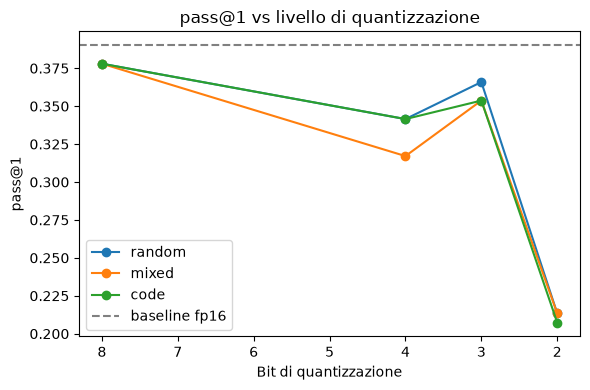

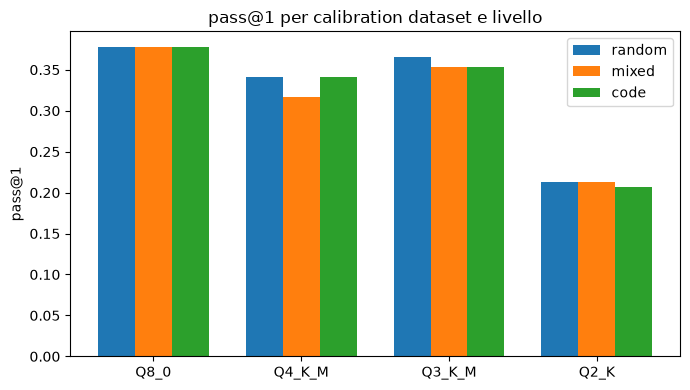

In [6]:
fig_dir = RESULTS_DIR / "figures"
line_path = fig_dir / "pass_at_1_vs_bits.png"
bar_path = fig_dir / "pass_at_1_grouped_bars.png"

if line_path.exists() and bar_path.exists():
    from PIL import Image
    display(Image.open(line_path))
    display(Image.open(bar_path))
else:
    print("PNG non trovati, ricostruisco i grafici dai dati.")
    bits = [8, 4, 3, 2]
    data = {
        "random": [0.3780, 0.3415, 0.3659, 0.2134],
        "mixed":  [0.3780, 0.3171, 0.3537, 0.2134],
        "code":   [0.3780, 0.3415, 0.3537, 0.2073],
    }
    baseline = 0.3902

    fig, ax = plt.subplots(figsize=(6, 4))
    for name, vals in data.items():
        ax.plot(bits, vals, marker="o", label=name)
    ax.axhline(baseline, color="gray", linestyle="--", label="baseline fp16")
    ax.invert_xaxis()
    ax.set_xlabel("Bit di quantizzazione")
    ax.set_ylabel("pass@1")
    ax.set_title("pass@1 vs livello di quantizzazione")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    import numpy as np
    levels = ["Q8_0", "Q4_K_M", "Q3_K_M", "Q2_K"]
    x = np.arange(len(levels))
    width = 0.25
    for i, (name, vals) in enumerate(data.items()):
        ax.bar(x + (i - 1) * width, vals, width, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(levels)
    ax.set_ylabel("pass@1")
    ax.set_title("pass@1 per calibration dataset e livello")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 4.5 Una cosa importante sui numeri: quanto sono "solidi"?

HumanEval ha **164 problemi**: risolverne uno in più o in meno vale circa **0.61 punti percentuali** di pass@1. Guardando le tabelle sopra, le differenze tra le tre calibration a parità di bit sono quasi sempre nell'ordine di 1-3 problemi su 164 (cioè 0.6-1.8 punti percentuali). Questo vuol dire che vanno lette come **segnali deboli/indicativi**, non come differenze solide dal punto di vista statistico — non ho ripetizioni multiple (un solo campione per problema, decoding greedy) e il benchmark non è enorme. 

## 5. Discussione

Un po' di osservazioni emerse guardando i numeri:

1. **A Q8_0 le tre calibration sono identiche** (0.3780). Ha senso: a 8 bit la quantizzazione è quasi lossless, quindi la imatrix — cioè il calibration dataset — incide pochissimo sul risultato finale. Il "danno" della compressione a questo livello è talmente piccolo che non emergono differenze tra le fonti di calibrazione.

2. **A Q2_K il crollo è netto e sostanzialmente uguale per tutte e tre le calibration** (~0.21, contro 0.39 della baseline, quasi -46% relativo). Qui la compressione è talmente aggressiva che non importa più tanto come viene calibrato: il modello perde comunque una fetta enorme di capacità. È un po' il segnale che a 2 bit si è oltre il punto in cui la calibrazione può "salvare" qualcosa.

3. **L'andamento non è perfettamente monotono rispetto ai bit.** Per `random` e `code`, Q3_K_M viene fuori leggermente migliore di Q4_K_M, il che a prima vista sembra strano (più bit dovrebbe voler dire sempre meglio). Più probabile che sia rumore statistico dato il numero limitato di problemi in HumanEval che una vera controtendenza.

4. **`mixed` è la calibration più fragile a Q4_K_M** (0.3171, il valore più basso a quel livello, quasi 2 punti sotto le altre due). Potrebbe essere un caso in cui mescolare codice e discussioni testuali "diluisce" l'importanza che l'imatrix assegna ai pesi più rilevanti per generare codice puro. Detto questo, restando nell'ordine di pochi problemi su 164, è da trattare con cautela.

5. **`random` va leggermente meglio o alla pari delle altre calibration nella maggior parte dei livelli.** L'intuizione "naturale" sarebbe che calibrare su dati in-domain (codice) protegga meglio le capacità di generazione di codice durante la compressione. Qui non sembra essere così — anzi, calibrare su testo generico (C4) non penalizza affatto, e in alcuni casi va persino meglio. Due letture possibili, entrambe plausibili:
   - la imatrix serve soprattutto a capire quali *pesi* sono statisticamente più attivati/importanti in generale, più che a "specializzare" il modello sul dominio del calibration set — quindi anche testo generico può individuare bene i pesi chiave;
   - oppure, semplicemente, con differenze così piccole (1-3 problemi su 164) stiamo guardando rumore, e con un benchmark più ampio o più campioni per problema il quadro potrebbe cambiare.

Quindi meriterebbe un benchmark più esteso per essere confermato o smentito.

## 6. Threats to Validity (deviazioni dal piano originale)

### 6.1 Calibration dataset sostitutivi a RedPajama

Il piano originale (e il paper AQLM di riferimento) usava `togethercomputer/RedPajama-Data-1T-Sample`. Questo dataset è stato **rimosso** da Hugging Face, verosimilmente per una contestazione di copyright (conteneva campioni di Books3, al centro di note controversie legali nel settore). La versione completa `RedPajama-Data-1T` esiste ancora, ma richiede uno script di caricamento Python personalizzato, e le versioni recenti della libreria `datasets` hanno **disabilitato l'esecuzione di script di dataset** per motivi di sicurezza — quindi non era più utilizzabile.

Ho sostituito con tre dataset equivalenti dal punto di vista concettuale ma in formato Parquet nativo, stabili e pubblici: `allenai/c4` (random), `codeparrot/codeparrot-clean-valid` (code), e una combinazione di quest'ultimo con `HuggingFaceH4/stack-exchange-preferences` (mixed). Coprono le stesse categorie concettuali (testo generico / codice / codice + discussioni tecniche) ma **non la stessa identica distribuzione** di RedPajama.

### 6.2 Solo Python nei calibration dataset, niente Java

Il piano originale prevedeva Python **e** Java nei dataset "Mixed"/"Code", per rispecchiare il paper AQLM. Dato che il benchmark di valutazione (HumanEval) è comunque solo Python, ho scelto fonti di calibrazione solo Python.

### 6.3 Metodo di quantizzazione diverso

- **llama.cpp k-quants** invece di AQLM: metodo di quantizzazione diverso, con caratteristiche di compressione/precisione non direttamente comparabili al 100% con AQLM

### 6.4 Un solo campione per problema (pass@1, k=1, decoding greedy)

Ho usato **decoding greedy con un solo campione**, per contenere i tempi di generazione su hardware limitato. Questo introduce più sensibilità al rumore statistico.

## 7. Conclusioni

Tornando alla domanda di ricerca iniziale — quanto perde in accuratezza un modello di code generation quando viene quantizzato, e se la calibrazione conta — i risultati di questa replica in scala ridotta dicono:

- **La perdita di accuratezza cresce in modo netto scendendo di bit**, ma non in modo lineare: a 8 bit è quasi trascurabile (-3.1%), a 4 e 3 bit diventa moderata (dal -6% al -19% circa a seconda della calibrazione), e a 2 bit diventa drastica (-45/-47%). C'è quindi una soglia oltre la quale la compressione comincia a "rompere" seriamente le capacità del modello, e in questo esperimento sembra collocarsi tra i 3 e i 2 bit.

- **Il calibration dataset conta, ma non enormemente**, e soprattutto **non nella direzione intuitiva**: calibrare su codice puro non protegge sistematicamente meglio rispetto a calibrare su testo generico. Anzi, `random` (C4) risulta spesso la scelta più solida o alla pari delle altre. Questo è un risultato che vale la pena approfondire con un benchmark più ampio prima di trarne conclusioni definitive, perché qui le differenze sono nell'ordine di pochi problemi su 164.

- A 8 bit e a 2 bit, agli estremi, la calibrazione conta pochissimo: a 8 bit perché la compressione è troppo leggera per farla emergere, a 2 bit perché è troppo aggressiva per essere "salvata" da una buona calibrazione.
